In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [58]:
df = pd.read_csv('/PyAi/tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [59]:
df.shape

(200, 2)

In [60]:
df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

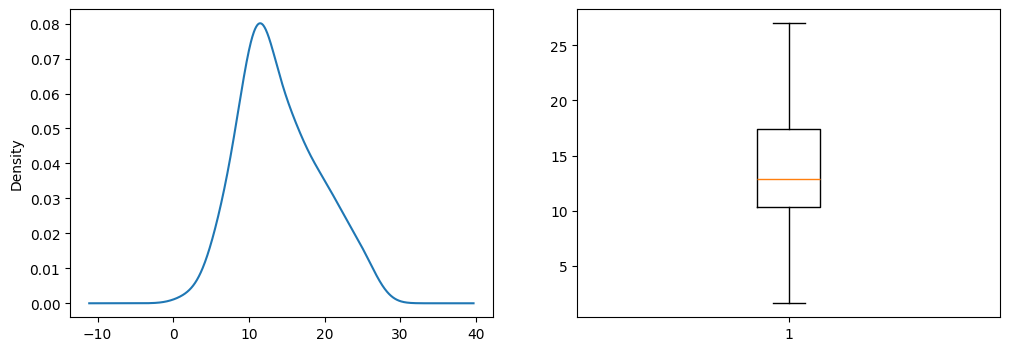

In [62]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Sales'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Sales'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

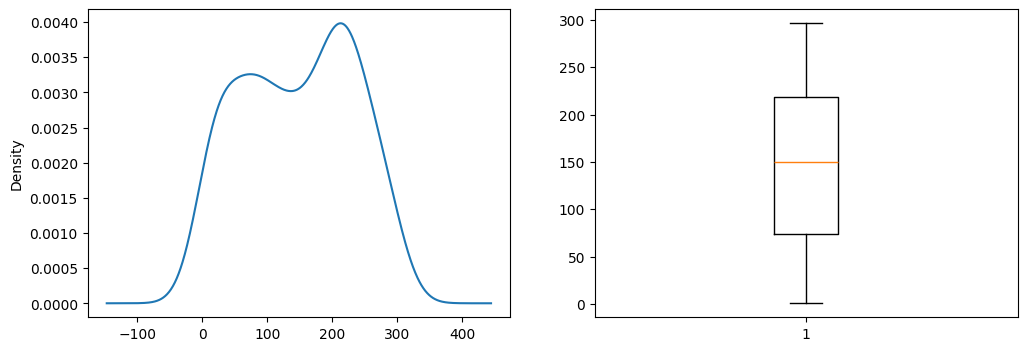

In [63]:
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['TV'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['TV'])
plt.show

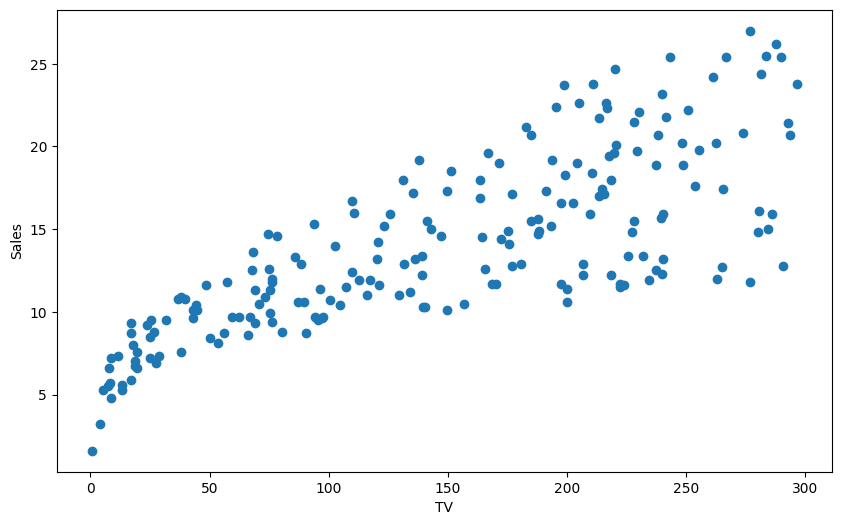

In [64]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['TV'], df['Sales'])
ax.set_xlabel('TV')
ax.set_ylabel('Sales')
plt.show()

In [65]:
df[['TV','Sales']].corr()

,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


,TV,Sales
TV,1.000000,0.782224
Sales,0.782224,1.000000


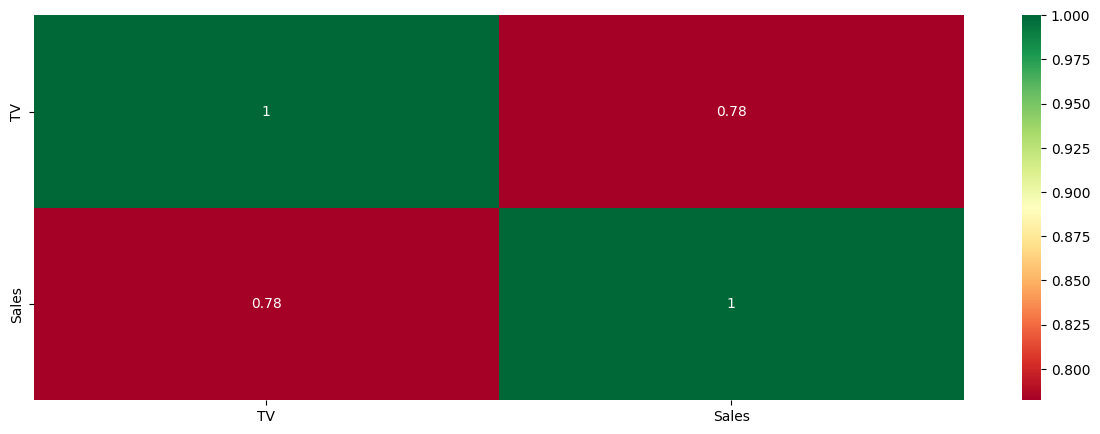

In [66]:
plt.figure(figsize=(15,5))
c = df.corr(numeric_only=True)
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

In [67]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [68]:
Q1 = df['TV'].quantile(0.25)
Q3 = df['TV'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['TV'] >= Q1 - 1.5*IQR) & (df['TV'] >= Q3 - 1.5*IQR)]
    

In [69]:
df.copy()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9
...,...,...
195,38.2,7.6
196,94.2,9.7
197,177.0,12.8
198,283.6,25.5


In [70]:
x = df['TV'].values
y = df['Sales'].values

#mean
x_mean = np.mean(x)
y_mean = np.mean(y)

#slope dan intercept
beta_1 = np.sum((x - x_mean)*(y-y_mean)) / np.sum((x - x_mean)**2)
beta_0 = y_mean - beta_1 * x_mean

In [71]:
df['Sales_Pred'] = beta_0 + beta_1 * df['TV']


In [72]:
df.columns

Index(['TV', 'Sales', 'Sales_Pred'], dtype='str')

In [73]:
df[['TV', 'Sales', 'Sales_Pred']]

,TV,Sales,Sales_Pred
0,230.1,22.1,17.952452
1,44.5,10.4,9.232886
2,17.2,9.3,7.950321
3,151.5,18.5,14.259791
4,180.8,12.9,15.636317
...,...,...,...
195,38.2,7.6,8.936910
196,94.2,9.7,11.567813
197,177.0,12.8,15.457792
198,283.6,25.5,20.465904


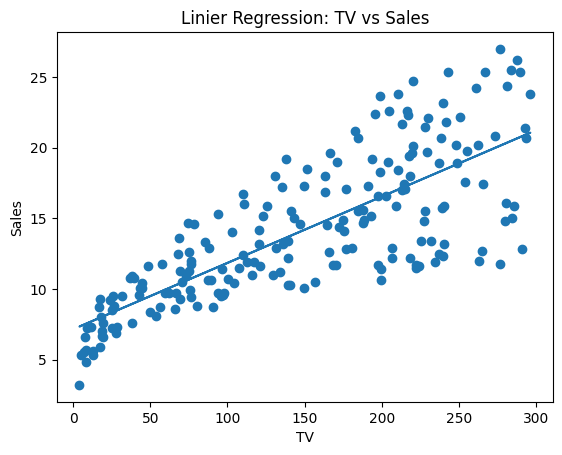

In [74]:
plt.figure()
plt.scatter(df['TV'], df['Sales'])
plt.plot(df['TV'], df['Sales_Pred'])
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Linier Regression: TV vs Sales')
plt.show()

,TV,Sales,Sales_Pred
TV,1.000000,0.778606,1.000000
Sales,0.778606,1.000000,0.778606
Sales_Pred,1.000000,0.778606,1.000000


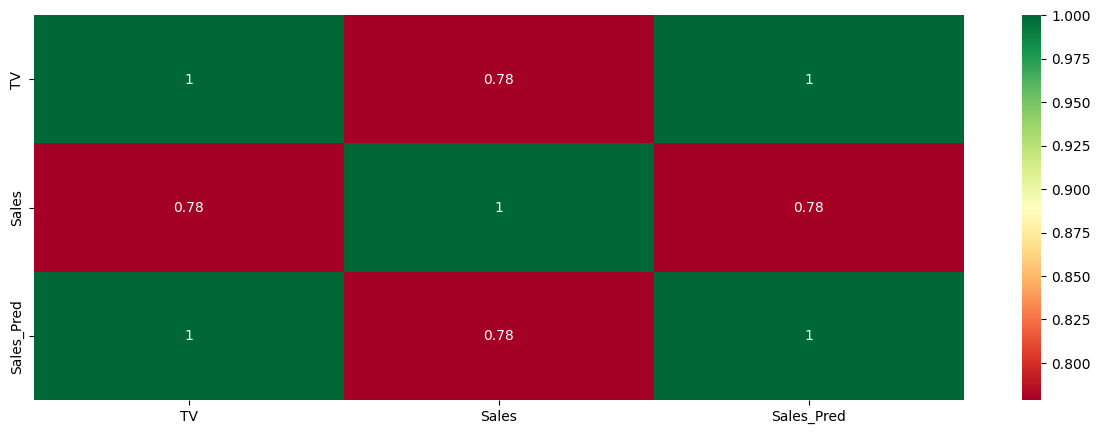

In [79]:
plt.figure(figsize=(15,5))
c = df.corr(numeric_only=True)
sns.heatmap(c, cmap="RdYlGn", annot=True)
c